In [21]:
import torch
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# Parameters
# ============================================================

mu_x0 = 3.0
var_x0 = 0.4
sigma_base = 0
var_z0 = var_x0 + sigma_base**2  # 4.4


sigma_base = 2
data='gaussian'  # 'gaussian' or 'mixture'
n_samples = 30000
eps_mean = 3.0

mu_z0 = mu_x0 + sigma_base * eps_mean
var_z0 = var_x0 + sigma_base**2


# Mixture parameters for X_0
mixture_weights = torch.tensor([0.5, 0.5], device=device)
mixture_means = torch.tensor([1, 5.0], device=device)
mixture_stds = torch.tensor([0.4, 0.4], device=device)


def sample_x0_mixture(batch_size):
    """
    Sample hidden clean latent X_0 from a 1D Gaussian mixture.

        X_0 ~ sum_k pi_k N(mu_k, std_k^2)
    """

    # sample component indices
    comp_ids = torch.multinomial(
        mixture_weights,
        num_samples=batch_size,
        replacement=True
    )

   
    means = mixture_means[comp_ids].reshape(batch_size, 1)
    stds = mixture_stds[comp_ids].reshape(batch_size, 1)

    # sample from selected Gaussian component
    x0 = means + stds * torch.randn(batch_size, 1, device=device)

    return x0

def sample_x0(batch_size, mu_x=3.0, var_x=0.4):
    std_x = torch.sqrt(torch.tensor(var_x, device=device))
    x0 = mu_x + std_x * torch.randn(batch_size, 1, device=device)
    return x0


def sample_z0_from_x0(x0):
    """
    Observation model:
    
        Z_0 = X_0 + sigma * eps_0, with eps_0 ~ N(eps_mean, 1)
    """
    eps0 = eps_mean + torch.randn_like(x0)
    z0 = x0 + sigma_base * eps0
    return z0


def sample_joint_data(batch_size, data):
    """
    Return both hidden X_0 and observed Z_0.
    """
    if data == 'mixture':
        x0 = sample_x0_mixture(batch_size)
    else:
        x0 = sample_x0(batch_size, mu_x=3.0, var_x=0.4)
    z0 = sample_z0_from_x0(x0)
    return x0, z0


def sample_data(batch_size, data=data):
    """
    The DDPM only observes Z_0.
    """
    _, z0 = sample_joint_data(batch_size, data=data)
    return z0

# Choix simple pour tester avec sigma_t^2 = sigma^2 / 2^t
T = 20

betas = torch.full((T,), 0.5, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


def extract(a, t, x_shape):
    out = a.gather(0, t)
    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))


def sigma2_t(t, x_shape):
    """
    sigma_t^2 = sigma_base^2 / 2^t
    """
    out = sigma_base**2 / (2.0 ** t.float())
    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

def extract_sigma2(t, x_shape):
    """
    Return sigma_t^2 reshaped for broadcasting.
    """
    out = sigma2_t(t, x_shape)
    return out.reshape(-1, *([1] * (len(x_shape) - 1)))
def extract_alpha_bar_prev(t, x_shape):
    """
    Return alpha_bar_{t-1}.
    For t=0, alpha_bar_{-1} is interpreted as 1,
    because X_{t-1}=X_0 at the final step.
    """
    out = torch.ones_like(t, dtype=torch.float, device=t.device)

    mask = t > 0
    if mask.any():
        out[mask] = alpha_bars.gather(0, t[mask] - 1)

    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

Dans ce notebook, on regarde ce qu'il se passe quand on est dans un cas où on a une forme explicite du score et on teste notre sampler dans ce cas : on se place dans le cas où les données sot distribuées selon une Gaussienne. La corruption consiste à leur ajouter un bruit gaussien avec une moyenne non nulle.

Comme on est dans un cas où tout est Gaussien, on peut calculer le score (et la dérivée du score pour la covariance de Tweedie) 


Dans le cas où $Z=\alpha X + \sigma \epsilon$, on a 
$$
\mathbb{E}[X \mid Z = z]
=
\frac{1}{\alpha}
\left(
z + \sigma^2 \nabla_z \log p_Z(z)
\right)
$$

et 

$$
\operatorname{Cov}(X \mid Z = z)
=
\frac{\sigma^2}{\alpha^2} I
+
\frac{\sigma^4}{\alpha^2}
\nabla_z^2 \log p_Z(z)
$$

Comme $Z_t$ est défini par le forward classique de DDPM et qu'on connait la loi de Z_0 via celle de X_0, on a une formule expicite pour le score 
$$\nabla_{z_t}\log f_t^Z(z_t)
=
-
\frac{
z_t
-
\sqrt{\overline{\alpha}_t}
\left(
\mu_{x_0}
+
\sigma_{\mathrm{base}}\mu_\epsilon
\right)
}{
\overline{\alpha}_t
\left(
\operatorname{var}_{x_0}
+
\sigma_{\mathrm{base}}^2
\right)
+
1-\overline{\alpha}_t
}.
$$

car le score d'une gaussienne $Y \sim \mathcal N(\mu, v)$ est donné par 
$$\nabla_y \log p_Y(y)=
=
-\frac{y-\mu}{v}.$$

De plus, 
$$Z_t
\sim
\mathcal N
\left(
\sqrt{\overline{\alpha}_t}
\left(
\mu_{x_0}+\sigma_{\mathrm{base}}\mu_\epsilon
\right),
\overline{\alpha}_t
\left(
\operatorname{var}_{x_0}+\sigma_{\mathrm{base}}^2
\right)
+
1-\overline{\alpha}_t
\right).$$

Pour la covariance de Tweedie, si on écrit 

$$
v_t
=
\beta_t+\alpha_t\sigma_{t-1}^2.$$
alors 
$$\operatorname{Cov}(X_{t-1}\mid Z_t=z)
=
\frac{1}{\alpha_t}
\left[
v_t I
+
v_t^2
\nabla_z^2 \log p_t^Z(z)
\right]$$
et 
$$\operatorname{Cov}(X_{t-1}\mid Z_t=z)
=
\frac{1}{\alpha_t}
\left[
\left(
\beta_t+\alpha_t\frac{\sigma^2}{2^{t-1}}
\right)I
+
\left(
\beta_t+\alpha_t\frac{\sigma^2}{2^{t-1}}
\right)^2
\nabla_z^2\log p_t^Z(z)
\right].$$

et dans le cas Gaussien 

In [22]:
@torch.no_grad()
def true_score_z_gaussian(zt, t):
    """
    True score of Z_t for:
        X_0 ~ N(mu_x0, var_x0)
        Z_0 = X_0 + sigma_base * epsilon_0
        epsilon_0 ~ N(eps_mean, I)

    Hence:
        Z_0 ~ N(mu_x0 + sigma_base * eps_mean,
                var_x0 + sigma_base^2).
    """

    alpha_bar_t = extract(alpha_bars, t, zt.shape)

    mu_z0 = mu_x0 + sigma_base * eps_mean
    var_z0 = var_x0 + sigma_base**2

    mu_z_t = torch.sqrt(alpha_bar_t) * mu_z0
    var_z_t = alpha_bar_t * var_z0 + (1.0 - alpha_bar_t)

    score = -(zt - mu_z_t) / var_z_t
    return score


In [36]:
@torch.no_grad()
def p_sample_hidden_x_true_score(zt, t):
    """
    Sample adapted but we use the actual Gaussian score of Z_t, which is known in this synthetic example.
    """

    beta_t = extract(betas, t, zt.shape)
    alpha_t = extract(alphas, t, zt.shape)
    alpha_bar_t = extract(alpha_bars, t, zt.shape)
    # sigma_{t-1}^2
    sigma_prev2 = extract_sigma2(t, zt.shape)
    sigma_prev = torch.sqrt(sigma_prev2)
    # delta_t = beta_t + alpha_t * sigma_{t-1}^2
    delta_t = beta_t + alpha_t * sigma_prev2
    
    # Bias induced by E[epsilon_{t-1}] = eps_mean.
    # Z_t | X_{t-1}=x is N(sqrt(alpha_t)*(x + sigma_{t-1} eps_mean), delta_t I).
    bias_t = torch.sqrt(alpha_t) * sigma_prev * eps_mean

    # True score of f_t^Z
    score = true_score_z_gaussian(zt, t)
    
    var_z0 = var_x0 + sigma_base**2
    var_z_t = alpha_bar_t * var_z0 + (1.0 - alpha_bar_t)
    hessian = -1.0 / var_z_t
    var_x_prev = (delta_t + (delta_t**2) * hessian) / alpha_t
    noise_x = torch.randn_like(zt)
    
    # 
    # Tweedie estimate: mean of X_{t-1} | Z_t
    x_prev_hat = (zt -bias_t + delta_t * score) / torch.sqrt(alpha_t)

    #Tweedie variance: var(X_{t-1} | Z_t) = delta_t / alpha_t

    x_prev = x_prev_hat + torch.sqrt(var_x_prev) * noise_x



    noise_z = torch.randn_like(zt)
    z_prev = x_prev + sigma_prev * eps_mean + torch.sqrt(sigma_prev2) * noise_z

    return z_prev, x_prev, x_prev_hat

In [37]:
@torch.no_grad()
def sample_hidden_x_from_z_ddpm( n_samples):
    """
    Full adapted reverse chain.

    Returns:
        x0_hat    : generated latent X_0
        z0_hat    : generated observed Z_0
        trajectory: selected intermediate states
    """
  
    zt = torch.randn(n_samples, 1, device=device)

    trajectory = []
    x_prev_hat = None

    for time_step in reversed(range(T)):
        t = torch.full((n_samples,), time_step, device=device, dtype=torch.long)

        z_prev, x_prev, x_prev_hat= p_sample_hidden_x_true_score( zt, t)

        if time_step in [T - 1, 200, 100, 50, 10, 0]:
            trajectory.append(
                {
                    "time": time_step,
                    "z_t": zt.detach().cpu(),
                    "x_prev": x_prev.detach().cpu(),
                    "x_prev_hat": x_prev_hat.detach().cpu(),
                    "z_prev": z_prev.detach().cpu(),
                }
            )

        zt = z_prev

    z0_hat = zt.detach().cpu()
    x0_hat = x_prev.detach().cpu()

    return x0_hat, z0_hat, trajectory

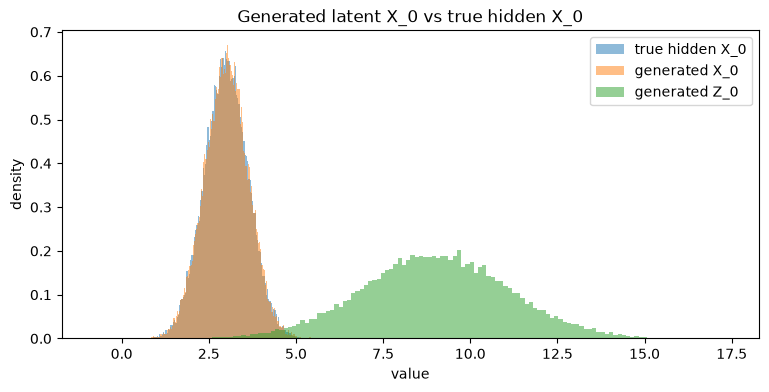

In [39]:
x0_gen, z0_gen, trajectory = sample_hidden_x_from_z_ddpm( n_samples=30000)

x0_real, z0_real = sample_joint_data(30000, data=data)
x0_real = x0_real.detach().cpu()
z0_real = z0_real.detach().cpu()

plt.figure(figsize=(9, 4))
plt.hist(x0_real.numpy(), bins=150, density=True, alpha=0.5, label="true hidden X_0")
plt.hist(x0_gen.numpy(), bins=150, density=True, alpha=0.5, label="generated X_0")
plt.hist(z0_real.numpy(), bins=150, density=True, alpha=0.5, label="generated Z_0")
plt.title("Generated latent X_0 vs true hidden X_0")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()